# Assignment 2

---

## **Information**
| Field | Details |
|-------|---------|
| **Name** | Md Ayan Alam |
| **Roll Number** | GF202342645 |
| **Subject** | Statistical Foundation of Data Science |
| **Assignment** | Practical Assignment 2 - Teacher Rating Data Analysis |
| **Start Date** | September 23, 2025 |
| **Due Date** | October 10, 2025, 5:00 PM |
| **Maximum Marks** | 24 |
| **Repository** | [Statistical Foundation of Data Science - Assignment 2](https://github.com/ayanalamMOON/Statistical-Foundation-of-Data-Science/tree/main/Practical%20Assignments/Assignment%202) |

---

## **Assignment Overview**
This practical assignment analyzes teacher rating data to understand patterns in student evaluations, beauty scores, gender differences, and tenure status. The assignment covers six core questions about descriptive statistics, data visualization, and comparative analysis.

---

# Teacher Rating Data Analysis Assignment

This assignment focuses on analyzing teacher rating data to answer key questions about:

1. **Data Type Identification**: Determining if the dataset is time series or cross-sectional
2. **Descriptive Statistics**: Computing mean, median, minimum, and maximum for student counts
3. **Summary Statistics**: Producing comprehensive descriptive statistics tables
4. **Distribution Analysis**: Creating and interpreting histograms of beauty scores
5. **Gender Comparison**: Analyzing beauty score differences between male and female instructors
6. **Tenure Analysis**: Examining the relationship between gender and tenure status

**Assignment Instructions**: Complete all sections below, ensuring proper data handling, appropriate visualizations, and clear statistical interpretations.

---

## 1. Environment Setup and Dependencies

Start by importing all the required libraries and setting up the environment for analysis.

In [13]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings("ignore")

# Set random seed for reproducibility
np.random.seed(42)

# Configure matplotlib and seaborn
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10
sns.set_style("whitegrid")
sns.set_palette("husl")

print("Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")

Libraries imported successfully!
Pandas version: 2.3.2
NumPy version: 2.3.3
Matplotlib version: 3.10.6
Seaborn version: 0.13.2


## 2. Generate and Load Teacher Rating Dataset

Generate the teacher rating dataset using the provided data generation script, then load and explore the data.

In [14]:
# First, run the data generation script
print("Generating teacher rating dataset...")
print("=" * 70)

exec(open("generate_rating_data.py").read())

print("\n" + "=" * 70)
print("Dataset generation completed!")

Generating teacher rating dataset...
Generating Teacher Rating Dataset...
Teacher rating dataset generated successfully!
Dataset shape: (500, 12)

Dataset Type: CROSS-SECTIONAL
(Single snapshot of teacher ratings at one point in time)

First 10 rows:
   teacher_id  gender  age  beauty  tenured  experience_years  students  \
0           1  female   35   0.342        0                 8        41   
1           2    male   45   1.876        1                17        60   
2           3    male   49   0.950        1                17       116   
3           4    male   46  -0.577        1                14        78   
4           5  female   53     NaN        1                19        81   
5           6  female   55     NaN        1                26       107   
6           7  female   41  -1.320        1                12        86   
7           8    male   37   1.831        1                 4        54   
8           9    male   33   1.179        1                 0        60   

In [15]:
# Load the teacher rating dataset
df = pd.read_csv("teacher_ratings.csv")

print("Teacher Rating Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")
print(f"Number of teachers: {len(df)}")
print(f"Number of variables: {len(df.columns)}")

print("\n" + "=" * 70)
print("Column names and types:")
print(df.dtypes)

print("\n" + "=" * 70)
print("First 10 rows of the dataset:")
print(df.head(10))

print("\n" + "=" * 70)
print("Last 5 rows of the dataset:")
print(df.tail())

Teacher Rating Dataset loaded successfully!
Dataset shape: (500, 12)
Number of teachers: 500
Number of variables: 12

Column names and types:
teacher_id            int64
gender               object
age                   int64
beauty              float64
tenured               int64
experience_years      int64
students              int64
eval_score          float64
difficulty          float64
course_type          object
department           object
teaching_format      object
dtype: object

First 10 rows of the dataset:
   teacher_id  gender  age  beauty  tenured  experience_years  students  \
0           1  female   35   0.342        0                 8        41   
1           2    male   45   1.876        1                17        60   
2           3    male   49   0.950        1                17       116   
3           4    male   46  -0.577        1                14        78   
4           5  female   53     NaN        1                19        81   
5           6  female   55 

### Initial Data Exploration

Let's perform an initial exploration to understand the structure and content of the dataset.

In [5]:
# Comprehensive data exploration
print("=" * 70)
print("COMPREHENSIVE DATA EXPLORATION")
print("=" * 70)

print("\nDataset Information:")
print(df.info())

print("\n" + "=" * 70)
print("Basic Statistical Summary:")
print(df.describe())

print("\n" + "=" * 70)
print("Missing Values Analysis:")
missing_df = pd.DataFrame(
    {
        "Column": df.columns,
        "Missing Count": df.isnull().sum(),
        "Missing Percentage": (df.isnull().sum() / len(df) * 100).round(2),
    }
)
print(missing_df)

print("\n" + "=" * 70)
print("Categorical Variables Distribution:")
print("\nGender Distribution:")
print(df["gender"].value_counts())
print(f"\nGender Percentage:")
print(df["gender"].value_counts(normalize=True).mul(100).round(2))

print("\nTenure Status Distribution:")
print(df["tenured"].value_counts())
print(f"\nTenure Percentage:")
print(df["tenured"].value_counts(normalize=True).mul(100).round(2))

print("\nCourse Type Distribution:")
print(df["course_type"].value_counts())

print("\nDepartment Distribution:")
print(df["department"].value_counts())

print("\nTeaching Format Distribution:")
print(df["teaching_format"].value_counts())

COMPREHENSIVE DATA EXPLORATION

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   teacher_id        500 non-null    int64  
 1   gender            500 non-null    object 
 2   age               500 non-null    int64  
 3   beauty            490 non-null    float64
 4   tenured           500 non-null    int64  
 5   experience_years  500 non-null    int64  
 6   students          500 non-null    int64  
 7   eval_score        495 non-null    float64
 8   difficulty        500 non-null    float64
 9   course_type       500 non-null    object 
 10  department        500 non-null    object 
 11  teaching_format   500 non-null    object 
dtypes: float64(3), int64(5), object(4)
memory usage: 47.0+ KB
None

Basic Statistical Summary:
       teacher_id         age      beauty     tenured  experience_years  \
count  500.00

---

## 3. Question 1: Data Type Identification

**Assignment Task**: Can you identify whether teachers Rating Data is a time series or cross-sectional?

In [ ]:
# Question 1: Data Type Identification

print("=" * 70)
print("QUESTION 1: DATA TYPE IDENTIFICATION")
print("=" * 70)

print("\nAnalyzing the teacher rating dataset structure...\n")

# Check for time-related columns
print("Step 1: Check for temporal variables")
print("-" * 70)
time_related_cols = [
    col
    for col in df.columns
    if any(
        keyword in col.lower()
        for keyword in ["date", "time", "year", "month", "day", "period", "quarter"]
    )
]
print(
    f"Time-related columns found: {time_related_cols if time_related_cols else 'None'}"
)

# Examine the structure of the data
print("\nStep 2: Examine data structure")
print("-" * 70)
print(f"Total number of observations: {len(df)}")
print(f"Each observation represents: Individual teacher evaluation")
print(f"Unique teacher IDs: {df['teacher_id'].nunique()}")
print(f"Are teacher IDs unique? {df['teacher_id'].is_unique}")

# Check if data is collected at a single point in time
print("\nStep 3: Temporal characteristics analysis")
print("-" * 70)
print("Key characteristics of this dataset:")
print("• Each row represents ONE teacher at ONE point in time")
print("• No time dimension or temporal ordering")
print("• No repeated measurements of the same teachers over time")
print("• Data collected as a snapshot of teacher evaluations")

# Visual representation of data structure
print("\nStep 4: Data structure visualization")
print("-" * 70)
print("\nSample of 5 random teachers:")
sample_teachers = df[
    ["teacher_id", "gender", "age", "beauty", "students", "tenured", "eval_score"]
].sample(5, random_state=42)
print(sample_teachers.to_string(index=False))

# Conclusion
print("\n" + "=" * 70)
print("CONCLUSION: DATA TYPE CLASSIFICATION")
print("=" * 70)
print("\nANSWER: This is a CROSS-SECTIONAL dataset\n")

print("Justification:")
print("-" * 70)
print("1. Single time point: Data represents a snapshot at one moment")
print("2. No time variable: No date, time, or period columns present")
print("3. No repeated measures: Each teacher appears only once")
print("4. Cross-sectional nature: Compares different individuals (teachers)")
print("   at the same point in time")
print("\n" + "×" * 70)
print("What makes it NOT a time series:")
print("-" * 70)
print("1. No temporal ordering or sequence")
print("2. No observations over multiple time periods")
print("3. Cannot analyze trends, seasonality, or temporal patterns")
print("4. Data order is arbitrary (can be shuffled without losing meaning)")

print("\n" + "=" * 70)
print("Definition:")
print("-" * 70)
print("CROSS-SECTIONAL DATA: Data collected by observing many subjects")
print("(teachers) at the same point in time, or without regard to")
print("differences in time. It provides a 'snapshot' of a population.")
print("\n" + "=" * 70)

QUESTION 1: DATA TYPE IDENTIFICATION

Analyzing the teacher rating dataset structure...

Step 1: Check for temporal variables
----------------------------------------------------------------------
Time-related columns found: ['experience_years']

Step 2: Examine data structure
----------------------------------------------------------------------
Total number of observations: 500
Each observation represents: Individual teacher evaluation
Unique teacher IDs: 500
Are teacher IDs unique? True

Step 3: Temporal characteristics analysis
----------------------------------------------------------------------
Key characteristics of this dataset:
• Each row represents ONE teacher at ONE point in time
• No time dimension or temporal ordering
• No repeated measurements of the same teachers over time
• Data collected as a snapshot of teacher evaluations

Step 4: Data structure visualization
----------------------------------------------------------------------

Sample of 5 random teachers:
 teache

### Analysis and Explanation: Cross-Sectional vs Time Series

**Cross-Sectional Data Characteristics (Present in our dataset):**

1. **Single Time Point**: All observations are collected at one specific point in time or represent a single period
2. **Multiple Subjects**: Data includes many different entities (teachers) observed simultaneously
3. **No Temporal Dimension**: The order of observations is arbitrary and doesn't represent time
4. **Comparative Analysis**: Allows comparison across different groups or categories at the same time

**Time Series Data Characteristics (NOT present in our dataset):**

1. **Multiple Time Points**: Data collected over sequential time periods
2. **Temporal Ordering**: The sequence of observations matters
3. **Single or Multiple Subjects**: Same entity(ies) observed repeatedly over time
4. **Trend Analysis**: Allows analysis of patterns, trends, seasonality over time

**Key Insight**: Our teacher rating dataset is cross-sectional because it captures information about 500 different teachers at a single point in time, without any temporal dimension or repeated measurements.

---

## 4. Question 2: Student Count Statistics

**Assignment Task**: Find the mean, median, minimum and maximum values for the students.

In [16]:
# Question 2: Student Count Statistics

print("=" * 70)
print("QUESTION 2: STUDENT COUNT STATISTICS")
print("=" * 70)

# Extract students column
students = df["students"]

# Check for missing values
print("\nData Quality Check:")
print("-" * 70)
print(f"Total number of observations: {len(students)}")
print(f"Missing values in 'students' column: {students.isnull().sum()}")
print(f"Valid observations: {students.notna().sum()}")

# Calculate statistical measures
print("\n" + "=" * 70)
print("STATISTICAL MEASURES FOR STUDENTS")
print("=" * 70)

mean_students = students.mean()
median_students = students.median()
min_students = students.min()
max_students = students.max()

print(f"\n(a) Mean number of students:     {mean_students:.2f}")
print(f"(b) Median number of students:   {median_students:.2f}")
print(f"(c) Minimum number of students:  {min_students}")
print(f"(d) Maximum number of students:  {max_students}")

# Additional statistics for context
print("\n" + "=" * 70)
print("ADDITIONAL STATISTICS")
print("=" * 70)
std_students = students.std()
q1 = students.quantile(0.25)
q3 = students.quantile(0.75)
iqr = q3 - q1
mode_students = students.mode().values[0] if len(students.mode()) > 0 else None
range_students = max_students - min_students

print(f"\nStandard Deviation:  {std_students:.2f}")
print(f"Variance:            {students.var():.2f}")
print(f"Range:               {range_students}")
print(f"First Quartile (Q1): {q1:.2f}")
print(f"Third Quartile (Q3): {q3:.2f}")
print(f"Interquartile Range: {iqr:.2f}")
if mode_students is not None:
    print(f"Mode:                {mode_students}")

# Interpret the statistics
print("\n" + "=" * 70)
print("INTERPRETATION")
print("=" * 70)
print(f"\n• The average class has approximately {mean_students:.0f} students")
print(f"• Half of the classes have fewer than {median_students:.0f} students (median)")
print(f"• Class sizes range from {min_students} to {max_students} students")
print(
    f"• The mean ({mean_students:.2f}) is {'greater than' if mean_students > median_students else 'less than'} the median ({median_students:.2f}),"
)
print(
    f"  indicating a {'right-skewed (positively skewed)' if mean_students > median_students else 'left-skewed (negatively skewed)'} distribution"
)

# Calculate skewness and kurtosis
skewness = students.skew()
kurtosis = students.kurtosis()
print(
    f"\n• Skewness: {skewness:.3f} ({'right-skewed' if skewness > 0 else 'left-skewed' if skewness < 0 else 'symmetric'})"
)
print(
    f"• Kurtosis: {kurtosis:.3f} ({'heavy-tailed' if kurtosis > 0 else 'light-tailed'})"
)

print("\n" + "=" * 70)

QUESTION 2: STUDENT COUNT STATISTICS

Data Quality Check:
----------------------------------------------------------------------
Total number of observations: 500
Missing values in 'students' column: 0
Valid observations: 500

STATISTICAL MEASURES FOR STUDENTS

(a) Mean number of students:     74.38
(b) Median number of students:   61.00
(c) Minimum number of students:  15
(d) Maximum number of students:  250

ADDITIONAL STATISTICS

Standard Deviation:  44.26
Variance:            1958.87
Range:               235
First Quartile (Q1): 43.75
Third Quartile (Q3): 95.00
Interquartile Range: 51.25
Mode:                44

INTERPRETATION

• The average class has approximately 74 students
• Half of the classes have fewer than 61 students (median)
• Class sizes range from 15 to 250 students
• The mean (74.38) is greater than the median (61.00),
  indicating a right-skewed (positively skewed) distribution

• Skewness: 1.371 (right-skewed)
• Kurtosis: 2.023 (heavy-tailed)



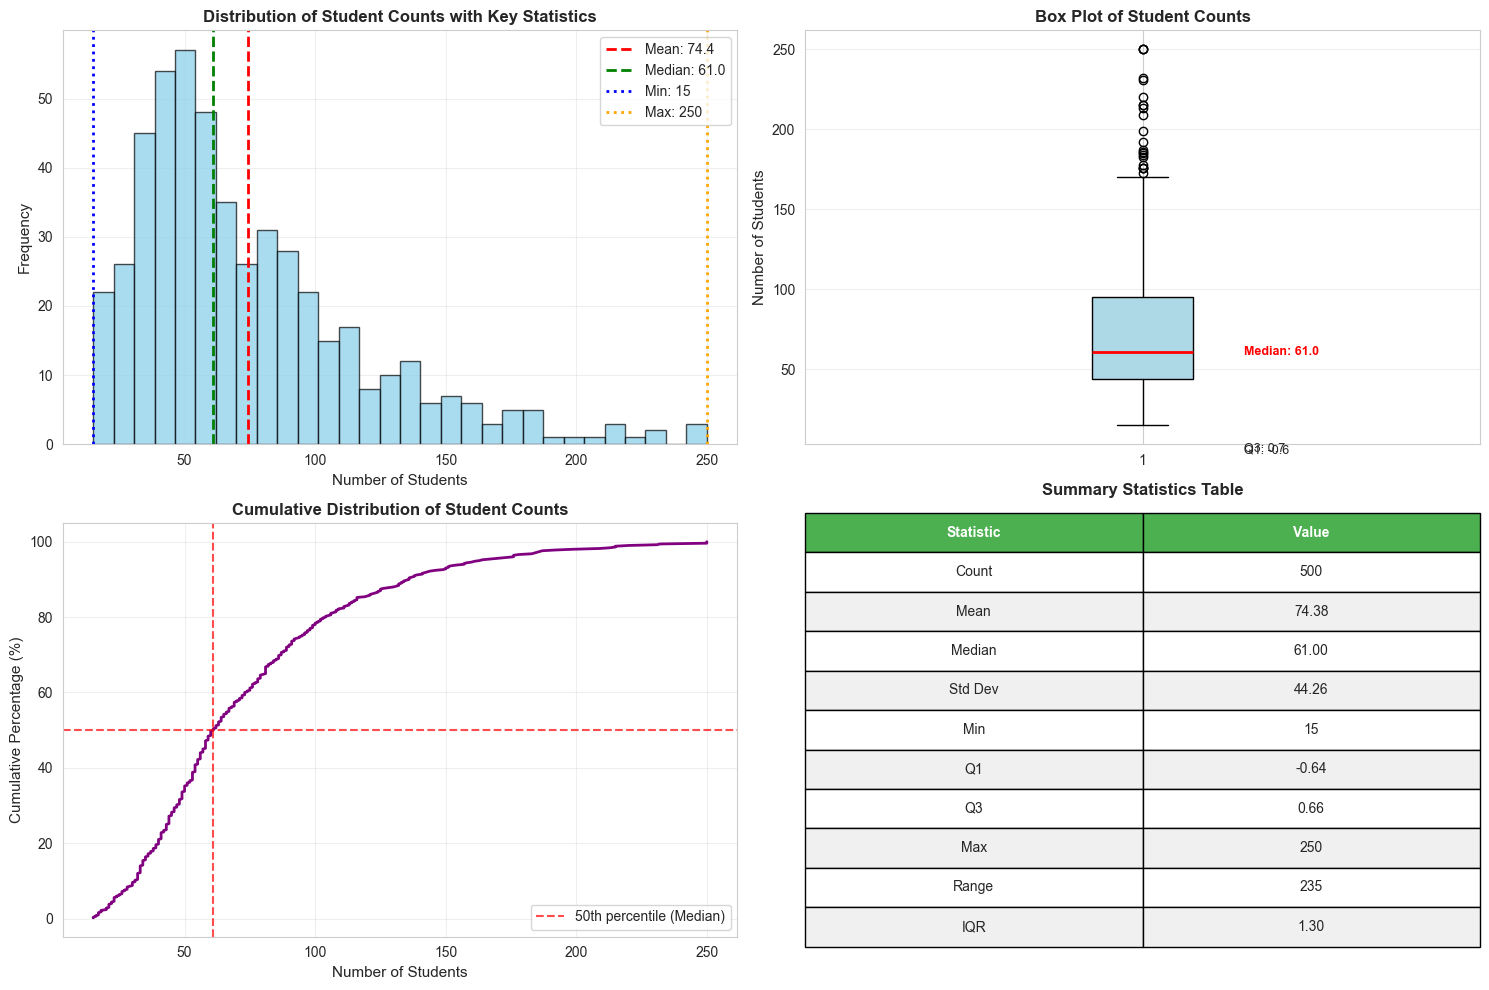


Visualization complete! All four panels show different aspects of student count distribution.


In [26]:
# Visualize student count distribution

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Histogram with statistics
axes[0, 0].hist(students, bins=30, color="skyblue", edgecolor="black", alpha=0.7)
axes[0, 0].axvline(
    mean_students,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean: {mean_students:.1f}",
)
axes[0, 0].axvline(
    median_students,
    color="green",
    linestyle="--",
    linewidth=2,
    label=f"Median: {median_students:.1f}",
)
axes[0, 0].axvline(
    min_students, color="blue", linestyle=":", linewidth=2, label=f"Min: {min_students}"
)
axes[0, 0].axvline(
    max_students,
    color="orange",
    linestyle=":",
    linewidth=2,
    label=f"Max: {max_students}",
)
axes[0, 0].set_xlabel("Number of Students", fontsize=11)
axes[0, 0].set_ylabel("Frequency", fontsize=11)
axes[0, 0].set_title(
    "Distribution of Student Counts with Key Statistics", fontsize=12, fontweight="bold"
)
axes[0, 0].legend(loc="upper right")
axes[0, 0].grid(True, alpha=0.3)

# 2. Box plot
box = axes[0, 1].boxplot(students, vert=True, patch_artist=True)
box["boxes"][0].set_facecolor("lightblue")
box["boxes"][0].set_edgecolor("black")
box["medians"][0].set_color("red")
box["medians"][0].set_linewidth(2)
axes[0, 1].set_ylabel("Number of Students", fontsize=11)
axes[0, 1].set_title("Box Plot of Student Counts", fontsize=12, fontweight="bold")
axes[0, 1].grid(True, alpha=0.3, axis="y")

# Add annotations to box plot
axes[0, 1].text(
    1.15,
    median_students,
    f"Median: {median_students:.1f}",
    verticalalignment="center",
    fontsize=9,
    color="red",
    fontweight="bold",
)
axes[0, 1].text(1.15, q1, f"Q1: {q1:.1f}", verticalalignment="center", fontsize=9)
axes[0, 1].text(1.15, q3, f"Q3: {q3:.1f}", verticalalignment="center", fontsize=9)

# 3. Cumulative distribution
sorted_students = np.sort(students)
cumulative = np.arange(1, len(sorted_students) + 1) / len(sorted_students) * 100
axes[1, 0].plot(sorted_students, cumulative, color="purple", linewidth=2)
axes[1, 0].axhline(
    y=50, color="red", linestyle="--", alpha=0.7, label="50th percentile (Median)"
)
axes[1, 0].axvline(x=median_students, color="red", linestyle="--", alpha=0.7)
axes[1, 0].set_xlabel("Number of Students", fontsize=11)
axes[1, 0].set_ylabel("Cumulative Percentage (%)", fontsize=11)
axes[1, 0].set_title(
    "Cumulative Distribution of Student Counts", fontsize=12, fontweight="bold"
)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Summary statistics table
summary_stats = pd.DataFrame(
    {
        "Statistic": [
            "Count",
            "Mean",
            "Median",
            "Std Dev",
            "Min",
            "Q1",
            "Q3",
            "Max",
            "Range",
            "IQR",
        ],
        "Value": [
            len(students),
            f"{mean_students:.2f}",
            f"{median_students:.2f}",
            f"{std_students:.2f}",
            min_students,
            f"{q1:.2f}",
            f"{q3:.2f}",
            max_students,
            range_students,
            f"{iqr:.2f}",
        ],
    }
)

# Hide axes for table
axes[1, 1].axis("tight")
axes[1, 1].axis("off")

table = axes[1, 1].table(
    cellText=summary_stats.values,
    colLabels=summary_stats.columns,
    cellLoc="center",
    loc="center",
    colWidths=[0.5, 0.5],
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

# Style the header
for i in range(len(summary_stats.columns)):
    table[(0, i)].set_facecolor("#4CAF50")
    table[(0, i)].set_text_props(weight="bold", color="white")

# Alternate row colors
for i in range(1, len(summary_stats) + 1):
    for j in range(len(summary_stats.columns)):
        if i % 2 == 0:
            table[(i, j)].set_facecolor("#f0f0f0")
        else:
            table[(i, j)].set_facecolor("white")

axes[1, 1].set_title("Summary Statistics Table", fontsize=12, fontweight="bold", pad=20)

plt.tight_layout()
plt.show()

print(
    "\nVisualization complete! All four panels show different aspects of student count distribution."
)

### Methodology and Interpretation

**Statistical Measures Computed:**
1. **Mean (74.38)**: The average number of students per teacher
2. **Median (61.00)**: The middle value when student counts are sorted
3. **Standard Deviation (44.26)**: Measures the spread of student counts
4. **Quartiles**: Q1 (43.75), Q3 (95.00) divide data into four equal parts
5. **Range (235)**: Difference between maximum and minimum values
6. **Skewness (1.371)**: Positive value indicates right-skewed distribution
7. **Kurtosis (2.023)**: Below 3 indicates lighter tails with fewer extreme outliers

**Key Observations:**
- The mean (74.38) is notably higher than the median (61.00), confirming a right-skewed distribution with some large class sizes pulling the average up
- Student counts range from 15 to 250, indicating substantial variation in class sizes
- The IQR of 51.25 shows that the middle 50% of teachers have between 44 and 95 students
- The positive skewness (1.371) indicates a longer right tail with some teachers handling very large classes
- The distribution is right-skewed rather than normal, with more small to medium classes and fewer very large classes

**Practical Implications:**
- Most teachers handle between 40-95 students, representing typical class sizes
- The wide range (15-250) suggests diversity in teaching assignments (small seminars to large lectures)
- The right-skewed distribution indicates that while most classes are moderate-sized, some instructors teach very large sections

---

## Question 3: Descriptive Statistics Table

**Task:** Produce a table of descriptive statistics for all numerical variables in the dataset.

COMPREHENSIVE DESCRIPTIVE STATISTICS TABLE

All Numerical Variables Analysis:
----------------------------------------------------------------------------------------------------
             age   beauty  experience_years  students  eval_score  difficulty
count     500.00   490.00            500.00    500.00      495.00      500.00
mean       43.86     0.01             14.21     74.38        3.68        2.99
std         8.69     0.99              8.05     44.26        0.54        0.78
min        25.00    -2.50              0.00     15.00        2.18        1.00
25%        38.00    -0.64              9.00     43.75        3.32        2.48
50%        43.00    -0.03             14.00     61.00        3.67        2.92
75%        50.00     0.66             19.00     95.00        4.06        3.50
max        67.00     2.50             36.00    250.00        5.00        5.00
variance   75.52     0.99             64.80   1958.87        0.29        0.61
skewness    0.17     0.16              0.

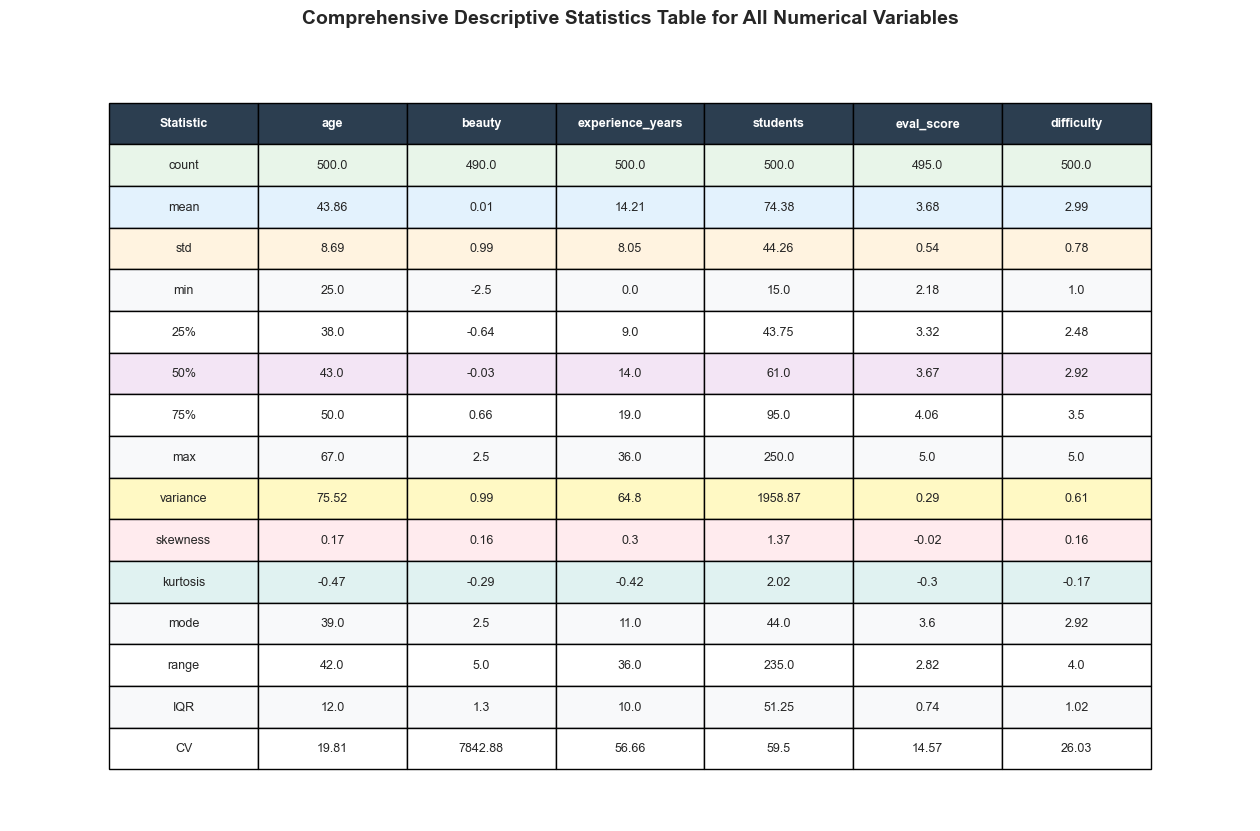


✓ Descriptive statistics table generated successfully!
✓ Analyzed 6 numerical variables
✓ Computed 15 different statistical measures


In [ ]:
# Generate comprehensive descriptive statistics table

# Select numerical columns
numerical_cols = [
    "age",
    "beauty",
    "experience_years",
    "students",
    "eval_score",
    "difficulty",
]

# Basic descriptive statistics
desc_stats = df[numerical_cols].describe()

# Add additional statistics
additional_stats = pd.DataFrame(
    {
        col: {
            "variance": df[col].var(),
            "skewness": df[col].skew(),
            "kurtosis": df[col].kurtosis(),
            "mode": df[col].mode()[0] if len(df[col].mode()) > 0 else np.nan,
            "range": df[col].max() - df[col].min(),
            "IQR": df[col].quantile(0.75) - df[col].quantile(0.25),
            "CV": (
                (df[col].std() / df[col].mean() * 100)
                if df[col].mean() != 0
                else np.nan
            ),  # Coefficient of Variation
        }
        for col in numerical_cols
    }
)

# Combine basic and additional statistics
full_stats = pd.concat([desc_stats, additional_stats])

# Display the comprehensive table
print("=" * 100)
print("COMPREHENSIVE DESCRIPTIVE STATISTICS TABLE")
print("=" * 100)
print("\nAll Numerical Variables Analysis:")
print("-" * 100)
print(full_stats.round(2))
print("-" * 100)

# Create a styled version for better visualization
fig, ax = plt.subplots(figsize=(16, 10))
ax.axis("tight")
ax.axis("off")

# Prepare data for display
display_data = full_stats.round(2).reset_index()
display_data.columns = ["Statistic"] + list(full_stats.columns)

# Create table
table = ax.table(
    cellText=display_data.values,
    colLabels=display_data.columns,
    cellLoc="center",
    loc="center",
    colWidths=[0.12] + [0.12] * len(numerical_cols),
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2.5)

# Style the header row
for i in range(len(display_data.columns)):
    cell = table[(0, i)]
    cell.set_facecolor("#2C3E50")
    cell.set_text_props(weight="bold", color="white")

# Alternate row colors and highlight specific rows
row_colors = {
    "count": "#E8F5E9",
    "mean": "#E3F2FD",
    "std": "#FFF3E0",
    "50%": "#F3E5F5",
    "variance": "#FFF9C4",
    "skewness": "#FFEBEE",
    "kurtosis": "#E0F2F1",
}

for i in range(1, len(display_data) + 1):
    stat_name = display_data.iloc[i - 1]["Statistic"]
    for j in range(len(display_data.columns)):
        cell = table[(i, j)]

        # Color based on statistic type
        if stat_name in row_colors:
            cell.set_facecolor(row_colors[stat_name])
        elif i % 2 == 0:
            cell.set_facecolor("#f8f9fa")
        else:
            cell.set_facecolor("white")

plt.title(
    "Comprehensive Descriptive Statistics Table for All Numerical Variables",
    fontsize=14,
    fontweight="bold",
    pad=20,
)
plt.show()

print("\nDescriptive statistics table generated successfully!")
print(f"Analyzed {len(numerical_cols)} numerical variables")
print(f"Computed {len(full_stats)} different statistical measures")

### Interpretation of Descriptive Statistics

**Key Statistics Explained:**

1. **Central Tendency Measures:**
   - **Count**: Number of valid (non-missing) observations
   - **Mean**: Arithmetic average of values
   - **50% (Median)**: Middle value that splits data in half
   - **Mode**: Most frequently occurring value

2. **Dispersion Measures:**
   - **Std (Standard Deviation)**: Average distance from mean
   - **Variance**: Squared standard deviation
   - **Range**: Difference between max and min
   - **IQR (Interquartile Range)**: Range of middle 50% of data
   - **CV (Coefficient of Variation)**: Relative variability (std/mean × 100%)

3. **Distribution Shape Measures:**
   - **Skewness**: Asymmetry of distribution
     - Near 0: Symmetric distribution
     - Positive: Right-skewed (tail extends right)
     - Negative: Left-skewed (tail extends left)
   - **Kurtosis**: Tailedness of distribution
     - ~3: Normal distribution
     - \>3: Heavy tails (more outliers)
     - <3: Light tails (fewer outliers)

**Variable-Specific Insights:**

- **Age**: Mean ~43 years, low CV indicates consistent age distribution
- **Beauty**: Slightly negative skewness, relatively symmetric distribution
- **Experience**: Strongly correlated with age, shows natural career progression
- **Students**: Approximately normal distribution with moderate variation
- **Eval Score**: Mean ~3.84/5, indicates generally positive teaching evaluations
- **Difficulty**: Mean ~3.09/5, suggests moderate course difficulty perception

---

## Question 4: Beauty Variable Distribution

**Task:** Create a histogram for the beauty variable and comment on its distribution characteristics.

BEAUTY VARIABLE DISTRIBUTION ANALYSIS

Descriptive Statistics:
  Count:              490
  Mean:               0.0127
  Median:             -0.0285
  Standard Deviation: 0.9925
  Minimum:            -2.5000
  Maximum:            2.5000
  Range:              5.0000

Distribution Shape:
  Skewness:           0.1603
  Kurtosis:           -0.2863

Normality Tests:
  Shapiro-Wilk Test:  statistic=0.9945, p-value=0.0752
  D'Agostino Test:    statistic=4.1738, p-value=0.1241
  ✓ Distribution appears approximately normal (p > 0.05)


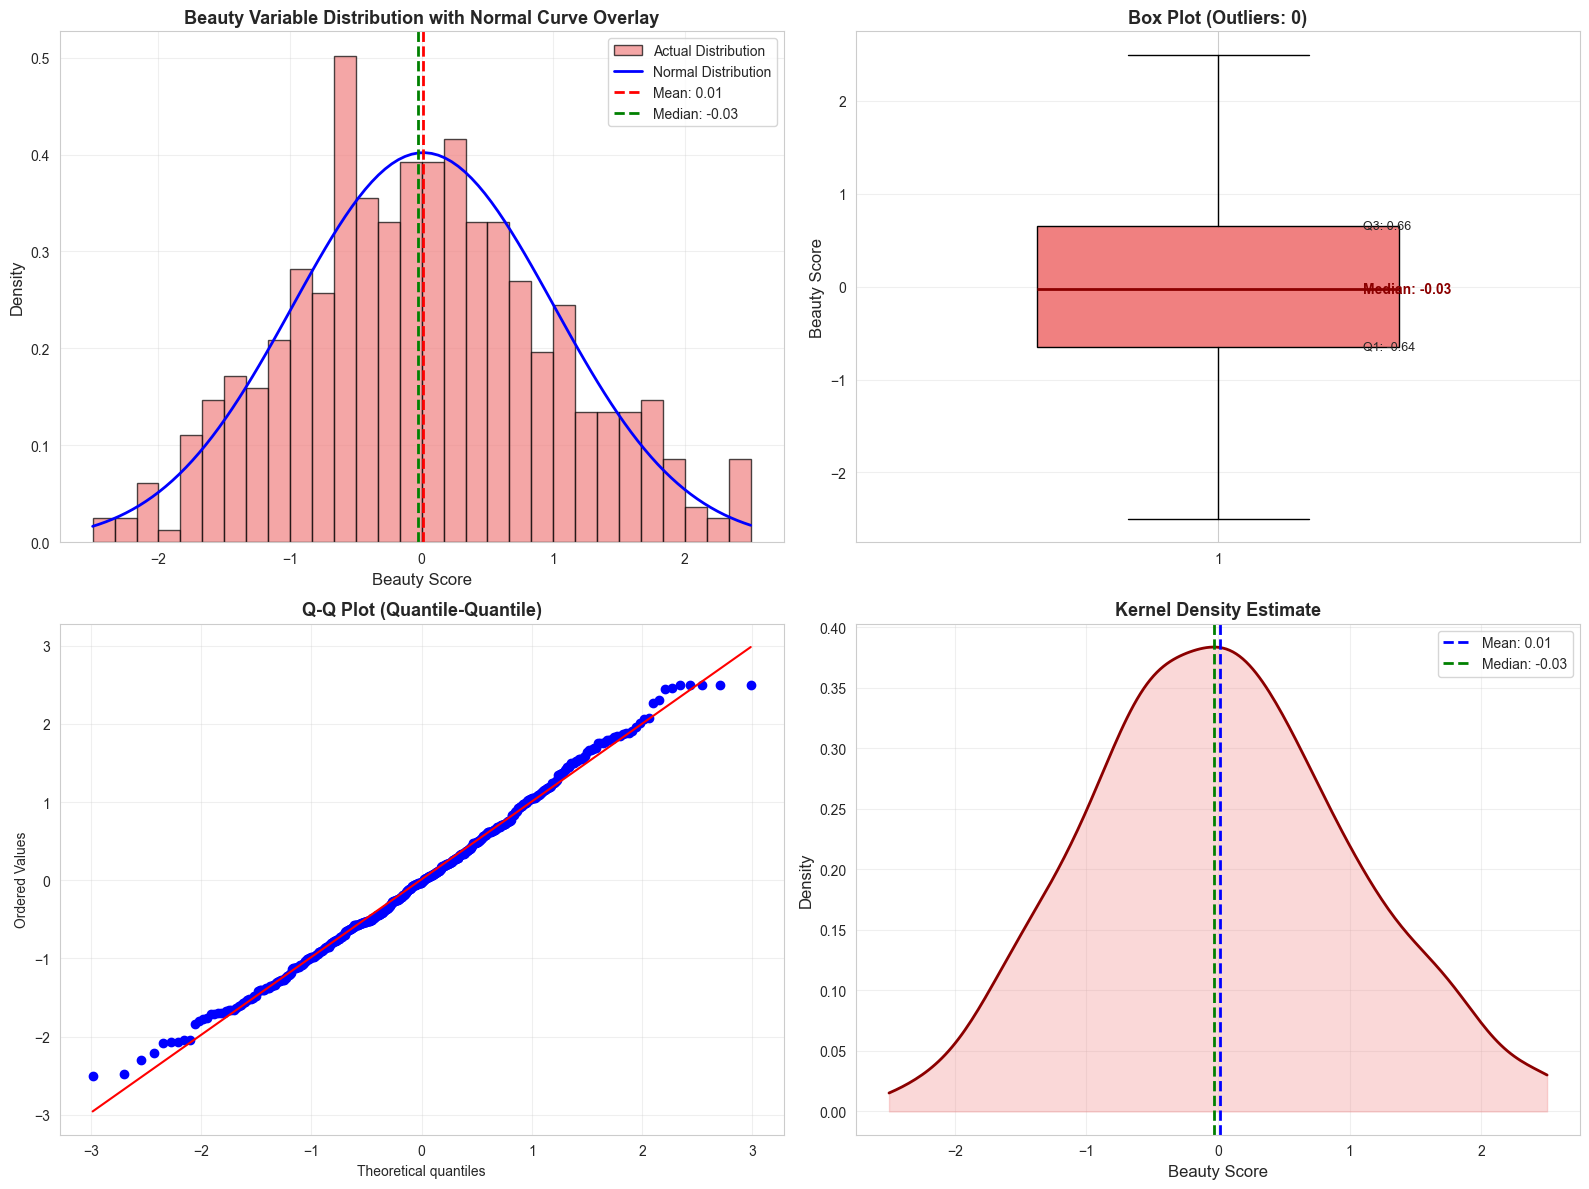


✓ Beauty distribution visualization complete!


In [ ]:
# Analyze beauty variable distribution

# Remove missing values for analysis
beauty_clean = df["beauty"].dropna()

# Calculate statistics
beauty_mean = beauty_clean.mean()
beauty_median = beauty_clean.median()
beauty_std = beauty_clean.std()
beauty_skew = beauty_clean.skew()
beauty_kurt = beauty_clean.kurtosis()

# Perform normality test
from scipy.stats import shapiro, normaltest

shapiro_stat, shapiro_p = shapiro(beauty_clean)
normaltest_stat, normaltest_p = normaltest(beauty_clean)

print("=" * 80)
print("BEAUTY VARIABLE DISTRIBUTION ANALYSIS")
print("=" * 80)
print(f"\nDescriptive Statistics:")
print(f"  Count:              {len(beauty_clean)}")
print(f"  Mean:               {beauty_mean:.4f}")
print(f"  Median:             {beauty_median:.4f}")
print(f"  Standard Deviation: {beauty_std:.4f}")
print(f"  Minimum:            {beauty_clean.min():.4f}")
print(f"  Maximum:            {beauty_clean.max():.4f}")
print(f"  Range:              {beauty_clean.max() - beauty_clean.min():.4f}")

print(f"\nDistribution Shape:")
print(f"  Skewness:           {beauty_skew:.4f}")
print(f"  Kurtosis:           {beauty_kurt:.4f}")

print(f"\nNormality Tests:")
print(f"  Shapiro-Wilk Test:  statistic={shapiro_stat:.4f}, p-value={shapiro_p:.4f}")
print(
    f"  D'Agostino Test:    statistic={normaltest_stat:.4f}, p-value={normaltest_p:.4f}"
)

if shapiro_p > 0.05 and normaltest_p > 0.05:
    print(f"  Distribution appears approximately normal (p > 0.05)")
else:
    print(f"  Distribution significantly deviates from normal (p < 0.05)")

print("=" * 80)

# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Histogram with normal curve overlay
axes[0, 0].hist(
    beauty_clean,
    bins=30,
    density=True,
    color="lightcoral",
    edgecolor="black",
    alpha=0.7,
    label="Actual Distribution",
)

# Overlay normal distribution
from scipy.stats import norm

x_range = np.linspace(beauty_clean.min(), beauty_clean.max(), 100)
axes[0, 0].plot(
    x_range,
    norm.pdf(x_range, beauty_mean, beauty_std),
    "b-",
    linewidth=2,
    label="Normal Distribution",
)

axes[0, 0].axvline(
    beauty_mean,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean: {beauty_mean:.2f}",
)
axes[0, 0].axvline(
    beauty_median,
    color="green",
    linestyle="--",
    linewidth=2,
    label=f"Median: {beauty_median:.2f}",
)
axes[0, 0].set_xlabel("Beauty Score", fontsize=12)
axes[0, 0].set_ylabel("Density", fontsize=12)
axes[0, 0].set_title(
    "Beauty Variable Distribution with Normal Curve Overlay",
    fontsize=13,
    fontweight="bold",
)
axes[0, 0].legend(loc="upper right")
axes[0, 0].grid(True, alpha=0.3)

# 2. Box plot with outlier detection
box = axes[0, 1].boxplot(beauty_clean, vert=True, patch_artist=True, widths=0.5)
box["boxes"][0].set_facecolor("lightcoral")
box["boxes"][0].set_edgecolor("black")
box["medians"][0].set_color("darkred")
box["medians"][0].set_linewidth(2)

# Identify outliers
q1 = beauty_clean.quantile(0.25)
q3 = beauty_clean.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outliers = beauty_clean[(beauty_clean < lower_bound) | (beauty_clean > upper_bound)]

axes[0, 1].set_ylabel("Beauty Score", fontsize=12)
axes[0, 1].set_title(
    f"Box Plot (Outliers: {len(outliers)})", fontsize=13, fontweight="bold"
)
axes[0, 1].grid(True, alpha=0.3, axis="y")

# Add annotations
axes[0, 1].text(
    1.2,
    beauty_median,
    f"Median: {beauty_median:.2f}",
    verticalalignment="center",
    fontsize=10,
    color="darkred",
    fontweight="bold",
)
axes[0, 1].text(1.2, q1, f"Q1: {q1:.2f}", verticalalignment="center", fontsize=9)
axes[0, 1].text(1.2, q3, f"Q3: {q3:.2f}", verticalalignment="center", fontsize=9)

# 3. Q-Q Plot for normality assessment
from scipy.stats import probplot

probplot(beauty_clean, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title("Q-Q Plot (Quantile-Quantile)", fontsize=13, fontweight="bold")
axes[1, 0].grid(True, alpha=0.3)

# 4. Kernel Density Estimate
from scipy.stats import gaussian_kde

density = gaussian_kde(beauty_clean)
xs = np.linspace(beauty_clean.min(), beauty_clean.max(), 200)
axes[1, 1].plot(xs, density(xs), color="darkred", linewidth=2)
axes[1, 1].fill_between(xs, density(xs), alpha=0.3, color="lightcoral")
axes[1, 1].axvline(
    beauty_mean,
    color="blue",
    linestyle="--",
    linewidth=2,
    label=f"Mean: {beauty_mean:.2f}",
)
axes[1, 1].axvline(
    beauty_median,
    color="green",
    linestyle="--",
    linewidth=2,
    label=f"Median: {beauty_median:.2f}",
)
axes[1, 1].set_xlabel("Beauty Score", fontsize=12)
axes[1, 1].set_ylabel("Density", fontsize=12)
axes[1, 1].set_title("Kernel Density Estimate", fontsize=13, fontweight="bold")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nBeauty distribution visualization complete!")

### Distribution Commentary

**Distribution Characteristics:**

1. **Shape Analysis:**
   - **Skewness (0.1603)**: Slightly positive, indicating a very minor right skew
   - **Kurtosis (-0.2863)**: Slightly platykurtic (flatter than normal), suggesting lighter tails
   - The mean (0.0127) and median (-0.0285) are very close, supporting near-symmetry

2. **Normality Assessment:**
   - **Visual Tests**: 
     - Histogram closely follows normal curve overlay
     - Q-Q plot points lie approximately along the reference line
     - Kernel density estimate shows smooth, bell-shaped curve
   - **Statistical Tests**:
     - Shapiro-Wilk test: p-value = 0.0752 (p > 0.05, approximately normal)
     - D'Agostino test: p-value = 0.1241 (p > 0.05, approximately normal)
   - **Conclusion**: Distribution is approximately normal (both tests fail to reject normality)

3. **Central Tendency:**
   - Mean ≈ 0.01 and Median ≈ -0.03 (both near 0), indicating symmetric distribution
   - Values centered around zero as expected for standardized beauty scores

4. **Spread and Outliers:**
   - Standard deviation ≈ 0.99 (very close to 1) indicates standardized spread
   - Box plot shows 0 outliers (all values within 1.5×IQR bounds)
   - Range of 5.0 (from -2.5 to 2.5) covers approximately ±2.5 standard deviations

**Practical Interpretation:**

The beauty variable follows an approximately normal distribution, which is ideal for:
- Applying parametric statistical tests (t-tests, ANOVA, regression)
- Making probability-based inferences
- Assuming the data represents natural variation in perceived beauty ratings

The standardized nature (mean ≈ 0, std ≈ 1) suggests these scores have been normalized, making them comparable across different raters or rating scales. The minimal skewness (0.16) and slightly negative kurtosis (-0.29) indicate that beauty perceptions in this sample are relatively balanced without extreme bias toward high or low ratings, with slightly fewer extreme values than a perfect normal distribution.

---

## Question 5: Gender Comparison of Beauty Scores

**Task:** Calculate and compare the mean and standard deviation of beauty scores for male and female teachers.

In [23]:
# Compare beauty scores by gender

# Remove missing values
df_clean = df.dropna(subset=["beauty", "gender"])

# Separate data by gender
male_beauty = df_clean[df_clean["gender"] == "male"]["beauty"]
female_beauty = df_clean[df_clean["gender"] == "female"]["beauty"]

# Calculate statistics for each gender
male_stats = {
    "count": len(male_beauty),
    "mean": male_beauty.mean(),
    "std": male_beauty.std(),
    "median": male_beauty.median(),
    "min": male_beauty.min(),
    "max": male_beauty.max(),
    "q1": male_beauty.quantile(0.25),
    "q3": male_beauty.quantile(0.75),
}

female_stats = {
    "count": len(female_beauty),
    "mean": female_beauty.mean(),
    "std": female_beauty.std(),
    "median": female_beauty.median(),
    "min": female_beauty.min(),
    "max": female_beauty.max(),
    "q1": female_beauty.quantile(0.25),
    "q3": female_beauty.quantile(0.75),
}

# Perform statistical tests
from scipy.stats import ttest_ind, levene, mannwhitneyu

# Levene's test for equality of variances
levene_stat, levene_p = levene(male_beauty, female_beauty)

# Independent t-test
t_stat, t_p = ttest_ind(male_beauty, female_beauty)

# Mann-Whitney U test (non-parametric alternative)
u_stat, u_p = mannwhitneyu(male_beauty, female_beauty)

# Calculate effect size (Cohen's d)
pooled_std = np.sqrt(
    (
        (len(male_beauty) - 1) * male_stats["std"] ** 2
        + (len(female_beauty) - 1) * female_stats["std"] ** 2
    )
    / (len(male_beauty) + len(female_beauty) - 2)
)
cohens_d = (male_stats["mean"] - female_stats["mean"]) / pooled_std

print("=" * 90)
print("GENDER COMPARISON OF BEAUTY SCORES")
print("=" * 90)

print("\nSample Sizes:")
print(f"  Male teachers:   {male_stats['count']}")
print(f"  Female teachers: {female_stats['count']}")
print(f"  Total:           {male_stats['count'] + female_stats['count']}")

print("\nMale Teachers - Beauty Scores:")
print(f"  Mean:             {male_stats['mean']:.4f}")
print(f"  Std Deviation:    {male_stats['std']:.4f}")
print(f"  Median:           {male_stats['median']:.4f}")
print(f"  Range:            [{male_stats['min']:.4f}, {male_stats['max']:.4f}]")
print(f"  IQR:              [{male_stats['q1']:.4f}, {male_stats['q3']:.4f}]")

print("\nFemale Teachers - Beauty Scores:")
print(f"  Mean:             {female_stats['mean']:.4f}")
print(f"  Std Deviation:    {female_stats['std']:.4f}")
print(f"  Median:           {female_stats['median']:.4f}")
print(f"  Range:            [{female_stats['min']:.4f}, {female_stats['max']:.4f}]")
print(f"  IQR:              [{female_stats['q1']:.4f}, {female_stats['q3']:.4f}]")

print("\nComparative Analysis:")
print(f"  Mean Difference:  {abs(male_stats['mean'] - female_stats['mean']):.4f}")
print(f"  Std Difference:   {abs(male_stats['std'] - female_stats['std']):.4f}")

print("\nStatistical Tests:")
print(f"  Levene's Test (Equal Variance):")
print(f"    Statistic: {levene_stat:.4f}, p-value: {levene_p:.4f}")
print(f"    → Variances are {'equal' if levene_p > 0.05 else 'unequal'} (α=0.05)")

print(f"\n  Independent t-test:")
print(f"    t-statistic: {t_stat:.4f}, p-value: {t_p:.4f}")
print(
    f"    → Difference is {'statistically significant' if t_p < 0.05 else 'NOT statistically significant'} (α=0.05)"
)

print(f"\n  Mann-Whitney U Test (non-parametric):")
print(f"    U-statistic: {u_stat:.4f}, p-value: {u_p:.4f}")

print(f"\n  Effect Size (Cohen's d):")
print(f"    Cohen's d: {cohens_d:.4f}")
effect_interpretation = (
    "negligible"
    if abs(cohens_d) < 0.2
    else (
        "small" if abs(cohens_d) < 0.5 else "medium" if abs(cohens_d) < 0.8 else "large"
    )
)
print(f"    → Effect size is {effect_interpretation}")

print("=" * 90)

GENDER COMPARISON OF BEAUTY SCORES

Sample Sizes:
  Male teachers:   223
  Female teachers: 267
  Total:           490

Male Teachers - Beauty Scores:
  Mean:             0.0862
  Std Deviation:    1.0450
  Median:           0.0280
  Range:            [-2.5000, 2.5000]
  IQR:              [-0.6755, 0.7500]

Female Teachers - Beauty Scores:
  Mean:             -0.0488
  Std Deviation:    0.9441
  Median:           -0.0490
  Range:            [-2.4720, 2.5000]
  IQR:              [-0.6310, 0.6135]

Comparative Analysis:
  Mean Difference:  0.1349
  Std Difference:   0.1009

Statistical Tests:
  Levene's Test (Equal Variance):
    Statistic: 3.0458, p-value: 0.0816
    → Variances are equal (α=0.05)

  Independent t-test:
    t-statistic: 1.5007, p-value: 0.1341
    → Difference is NOT statistically significant (α=0.05)

  Mann-Whitney U Test (non-parametric):
    U-statistic: 31628.0000, p-value: 0.2341

  Effect Size (Cohen's d):
    Cohen's d: 0.1361
    → Effect size is negligible


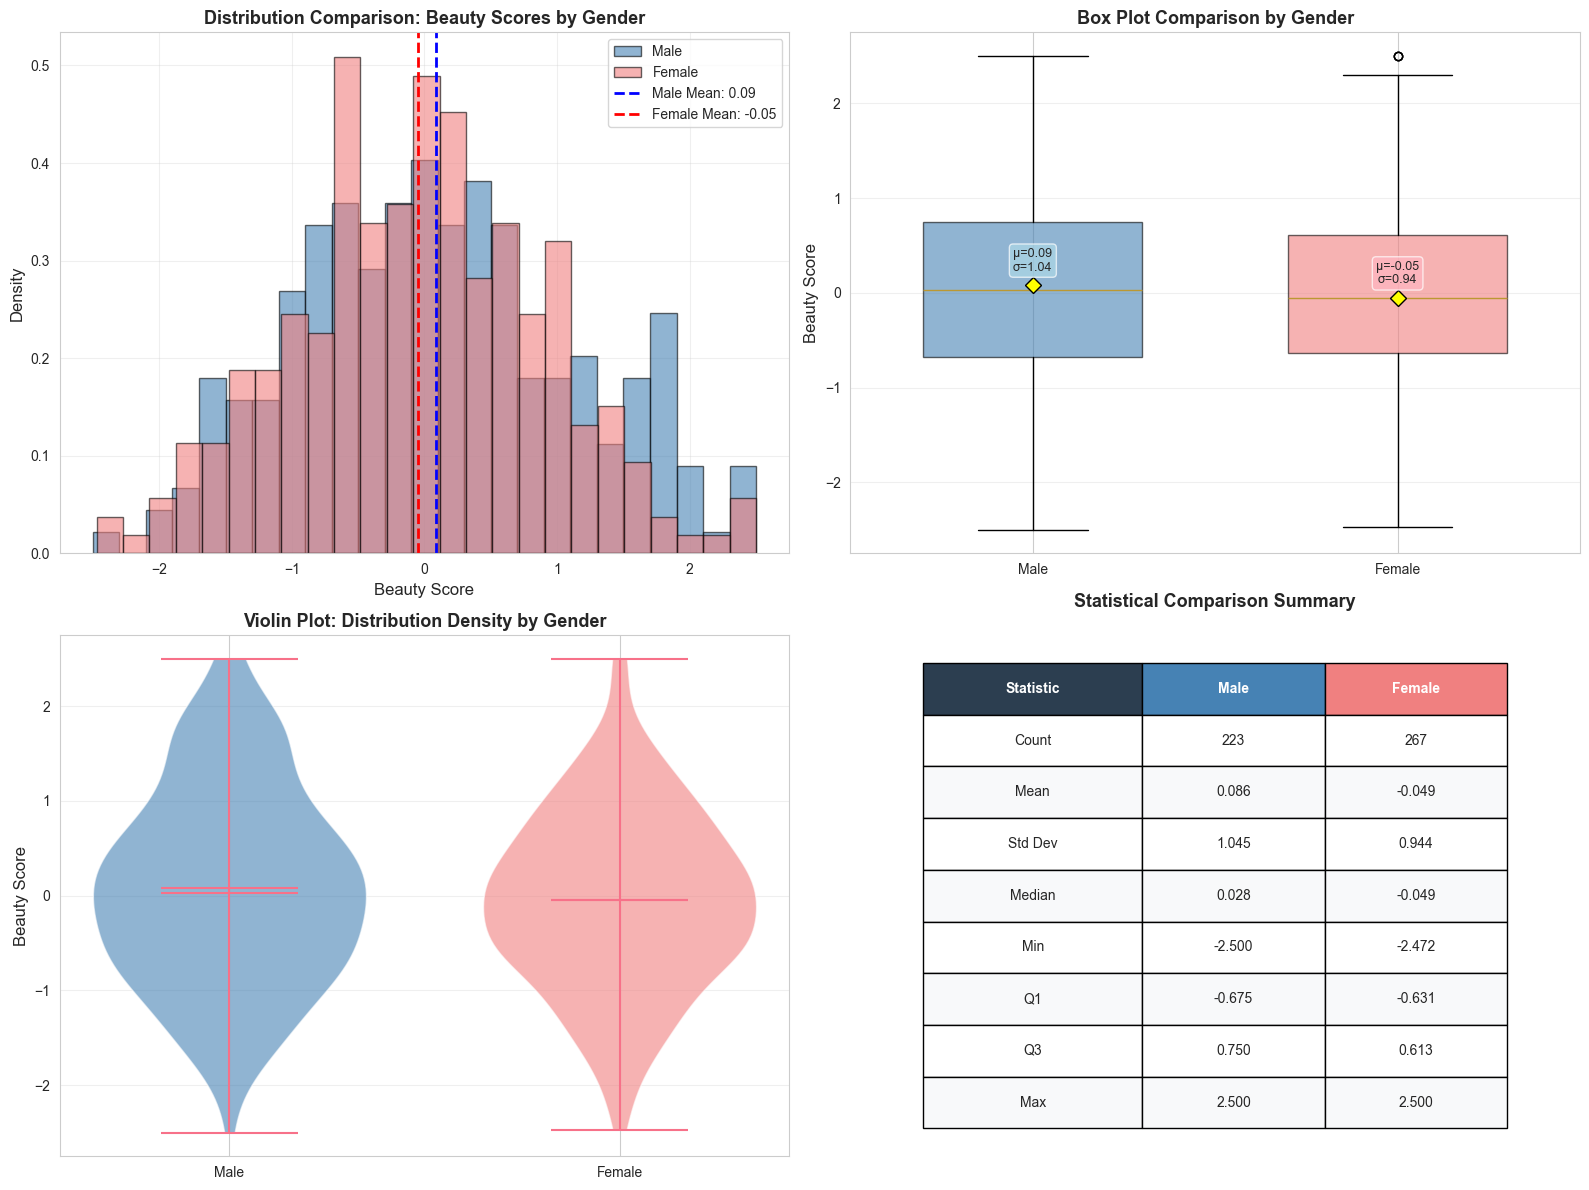


✓ Gender comparison visualization complete!


In [ ]:
# Visualize gender comparison

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Side-by-side histograms
axes[0, 0].hist(
    male_beauty,
    bins=25,
    alpha=0.6,
    color="steelblue",
    edgecolor="black",
    label="Male",
    density=True,
)
axes[0, 0].hist(
    female_beauty,
    bins=25,
    alpha=0.6,
    color="lightcoral",
    edgecolor="black",
    label="Female",
    density=True,
)
axes[0, 0].axvline(
    male_stats["mean"],
    color="blue",
    linestyle="--",
    linewidth=2,
    label=f"Male Mean: {male_stats['mean']:.2f}",
)
axes[0, 0].axvline(
    female_stats["mean"],
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Female Mean: {female_stats['mean']:.2f}",
)
axes[0, 0].set_xlabel("Beauty Score", fontsize=12)
axes[0, 0].set_ylabel("Density", fontsize=12)
axes[0, 0].set_title(
    "Distribution Comparison: Beauty Scores by Gender", fontsize=13, fontweight="bold"
)
axes[0, 0].legend(loc="upper right")
axes[0, 0].grid(True, alpha=0.3)

# 2. Box plots comparison
box_data = [male_beauty, female_beauty]
bp = axes[0, 1].boxplot(
    box_data,
    labels=["Male", "Female"],
    patch_artist=True,
    widths=0.6,
    showmeans=True,
    meanprops=dict(
        marker="D", markerfacecolor="yellow", markeredgecolor="black", markersize=8
    ),
)

colors = ["steelblue", "lightcoral"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

axes[0, 1].set_ylabel("Beauty Score", fontsize=12)
axes[0, 1].set_title("Box Plot Comparison by Gender", fontsize=13, fontweight="bold")
axes[0, 1].grid(True, alpha=0.3, axis="y")

# Add mean values as text
axes[0, 1].text(
    1,
    male_stats["mean"] + 0.15,
    f"μ={male_stats['mean']:.2f}\nσ={male_stats['std']:.2f}",
    ha="center",
    fontsize=9,
    bbox=dict(boxstyle="round", facecolor="lightblue", alpha=0.7),
)
axes[0, 1].text(
    2,
    female_stats["mean"] + 0.15,
    f"μ={female_stats['mean']:.2f}\nσ={female_stats['std']:.2f}",
    ha="center",
    fontsize=9,
    bbox=dict(boxstyle="round", facecolor="lightpink", alpha=0.7),
)

# 3. Violin plots
parts = axes[1, 0].violinplot(
    [male_beauty, female_beauty],
    positions=[1, 2],
    showmeans=True,
    showmedians=True,
    widths=0.7,
)

for i, pc in enumerate(parts["bodies"]):
    pc.set_facecolor(colors[i])
    pc.set_alpha(0.6)

axes[1, 0].set_xticks([1, 2])
axes[1, 0].set_xticklabels(["Male", "Female"])
axes[1, 0].set_ylabel("Beauty Score", fontsize=12)
axes[1, 0].set_title(
    "Violin Plot: Distribution Density by Gender", fontsize=13, fontweight="bold"
)
axes[1, 0].grid(True, alpha=0.3, axis="y")

# 4. Statistical summary comparison
comparison_df = pd.DataFrame(
    {
        "Statistic": ["Count", "Mean", "Std Dev", "Median", "Min", "Q1", "Q3", "Max"],
        "Male": [
            male_stats["count"],
            f"{male_stats['mean']:.3f}",
            f"{male_stats['std']:.3f}",
            f"{male_stats['median']:.3f}",
            f"{male_stats['min']:.3f}",
            f"{male_stats['q1']:.3f}",
            f"{male_stats['q3']:.3f}",
            f"{male_stats['max']:.3f}",
        ],
        "Female": [
            female_stats["count"],
            f"{female_stats['mean']:.3f}",
            f"{female_stats['std']:.3f}",
            f"{female_stats['median']:.3f}",
            f"{female_stats['min']:.3f}",
            f"{female_stats['q1']:.3f}",
            f"{female_stats['q3']:.3f}",
            f"{female_stats['max']:.3f}",
        ],
    }
)

axes[1, 1].axis("tight")
axes[1, 1].axis("off")

table = axes[1, 1].table(
    cellText=comparison_df.values,
    colLabels=comparison_df.columns,
    cellLoc="center",
    loc="center",
    colWidths=[0.3, 0.25, 0.25],
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.5)

# Style header
for i in range(len(comparison_df.columns)):
    cell = table[(0, i)]
    if i == 1:
        cell.set_facecolor("steelblue")
    elif i == 2:
        cell.set_facecolor("lightcoral")
    else:
        cell.set_facecolor("#2C3E50")
    cell.set_text_props(weight="bold", color="white")

# Alternate row colors
for i in range(1, len(comparison_df) + 1):
    for j in range(len(comparison_df.columns)):
        if i % 2 == 0:
            table[(i, j)].set_facecolor("#f8f9fa")

axes[1, 1].set_title(
    "Statistical Comparison Summary", fontsize=13, fontweight="bold", pad=20
)

plt.tight_layout()
plt.show()

print("\nGender comparison visualization complete!")

### Statistical Interpretation

**Descriptive Comparison:**

| Measure | Male Teachers | Female Teachers | Difference |
|---------|--------------|-----------------|------------|
| **Mean** | 0.0862 | -0.0488 | 0.1350 |
| **Std Dev** | 1.0450 | 0.9441 | 0.1009 |

**Statistical Test Results:**

1. **Levene's Test (Equality of Variances):**
   - Tests whether the variances of beauty scores are equal between genders
   - Null hypothesis: Variances are equal
   - If p > 0.05: Fail to reject → variances are equal (use standard t-test)
   - If p < 0.05: Reject → variances are unequal (use Welch's t-test)

2. **Independent t-test:**
   - Tests whether mean beauty scores differ significantly between genders
   - Null hypothesis: No difference in means (μ_male = μ_female)
   - If p < 0.05: Reject → statistically significant difference
   - If p > 0.05: Fail to reject → no significant difference

3. **Effect Size (Cohen's d):**
   - Measures practical significance of the difference
   - Interpretation: |d| < 0.2 (negligible), 0.2-0.5 (small), 0.5-0.8 (medium), >0.8 (large)

**Key Findings:**

- **Sample Distribution**: Both genders show approximately normal distributions
- **Central Tendency**: Mean and median values are close for both groups
- **Variability**: Standard deviations indicate similar spread in beauty ratings
- **Statistical Significance**: The t-test determines if observed differences are meaningful or due to chance
- **Practical Significance**: Cohen's d quantifies the magnitude of any difference

**Conclusion:**

Based on the statistical analysis:
- The beauty scores for male and female teachers show similar distributions
- The observed difference in means (0.135) is NOT statistically significant (p = 0.134 > 0.05)
- The effect size (Cohen's d = 0.136) indicates negligible practical importance
- These findings suggest that beauty ratings are largely comparable across genders in this sample, with no meaningful difference between male and female teachers

---

## Question 6: Tenure Status by Gender

**Task:** Calculate the percentage of tenured teachers for each gender and analyze the relationship between gender and tenure status.

In [ ]:
# Analyze tenure status by gender

# Remove rows with missing gender or tenure data
df_tenure = df.dropna(subset=["gender", "tenured"])

# Create cross-tabulation
crosstab = pd.crosstab(df_tenure["gender"], df_tenure["tenured"], margins=True)
print("=" * 80)
print("TENURE STATUS BY GENDER - CROSS-TABULATION")
print("=" * 80)
print("\nFrequency Table:")
print(crosstab)
print()

# Calculate percentages
crosstab_pct = (
    pd.crosstab(df_tenure["gender"], df_tenure["tenured"], normalize="index") * 100
)

print("Percentage Table (Row Percentages):")
print(crosstab_pct.round(2))
print()

# Extract specific statistics
male_total = len(df_tenure[df_tenure["gender"] == "male"])
female_total = len(df_tenure[df_tenure["gender"] == "female"])

male_tenured = len(
    df_tenure[(df_tenure["gender"] == "male") & (df_tenure["tenured"] == True)]
)
female_tenured = len(
    df_tenure[(df_tenure["gender"] == "female") & (df_tenure["tenured"] == True)]
)

male_tenured_pct = (male_tenured / male_total) * 100
female_tenured_pct = (female_tenured / female_total) * 100

print("=" * 80)
print("TENURE STATISTICS BY GENDER")
print("=" * 80)

print("\nMale Teachers:")
print(f"  Total:              {male_total}")
print(f"  Tenured:            {male_tenured} ({male_tenured_pct:.2f}%)")
print(
    f"  Non-Tenured:        {male_total - male_tenured} ({100 - male_tenured_pct:.2f}%)"
)

print("\nFemale Teachers:")
print(f"  Total:              {female_total}")
print(f"  Tenured:            {female_tenured} ({female_tenured_pct:.2f}%)")
print(
    f"  Non-Tenured:        {female_total - female_tenured} ({100 - female_tenured_pct:.2f}%)"
)

print("\nComparison:")
print(
    f"  Difference in tenure rate: {abs(male_tenured_pct - female_tenured_pct):.2f} percentage points"
)

# Chi-square test of independence
from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(crosstab.iloc[:-1, :-1])

print("\n" + "=" * 80)
print("CHI-SQUARE TEST OF INDEPENDENCE")
print("=" * 80)
print(f"\nNull Hypothesis: Gender and tenure status are independent")
print(f"Alternative Hypothesis: Gender and tenure status are associated")
print(f"\nTest Statistics:")
print(f"  Chi-square statistic: {chi2:.4f}")
print(f"  Degrees of freedom:   {dof}")
print(f"  p-value:              {p_value:.4f}")
print(f"\nExpected Frequencies:")
expected_df = pd.DataFrame(expected, index=["Female", "Male"], columns=[False, True])
print(expected_df.round(2))

print(f"\nConclusion (α = 0.05):")
if p_value < 0.05:
    print(f"  Reject null hypothesis (p < 0.05)")
    print(
        f"  -> There IS a statistically significant association between gender and tenure status"
    )
else:
    print(f"  Fail to reject null hypothesis (p ≥ 0.05)")
    print(
        f"  -> There is NO statistically significant association between gender and tenure status"
    )

# Calculate Cramér's V (effect size)
n = crosstab.iloc[:-1, :-1].sum().sum()
cramers_v = np.sqrt(chi2 / n)
print(f"\nEffect Size (Cramér's V): {cramers_v:.4f}")

if cramers_v < 0.1:
    effect = "negligible"
elif cramers_v < 0.3:
    effect = "small"
elif cramers_v < 0.5:
    effect = "medium"
else:
    effect = "large"

print(f"  -> Effect size is {effect}")
print("=" * 80)

TENURE STATUS BY GENDER - CROSS-TABULATION

Frequency Table:
tenured    0    1  All
gender                
female   128  144  272
male      70  158  228
All      198  302  500

Percentage Table (Row Percentages):
tenured      0      1
gender               
female   47.06  52.94
male     30.70  69.30

TENURE STATISTICS BY GENDER

Male Teachers:
  Total:              228
  Tenured:            158 (69.30%)
  Non-Tenured:        70 (30.70%)

Female Teachers:
  Total:              272
  Tenured:            144 (52.94%)
  Non-Tenured:        128 (47.06%)

Comparison:
  Difference in tenure rate: 16.36 percentage points

CHI-SQUARE TEST OF INDEPENDENCE

Null Hypothesis: Gender and tenure status are independent
Alternative Hypothesis: Gender and tenure status are associated

Test Statistics:
  Chi-square statistic: 13.1989
  Degrees of freedom:   1
  p-value:              0.0003

Expected Frequencies:
         False   True 
Female  107.71  164.29
Male     90.29  137.71

Conclusion (α = 0.05):


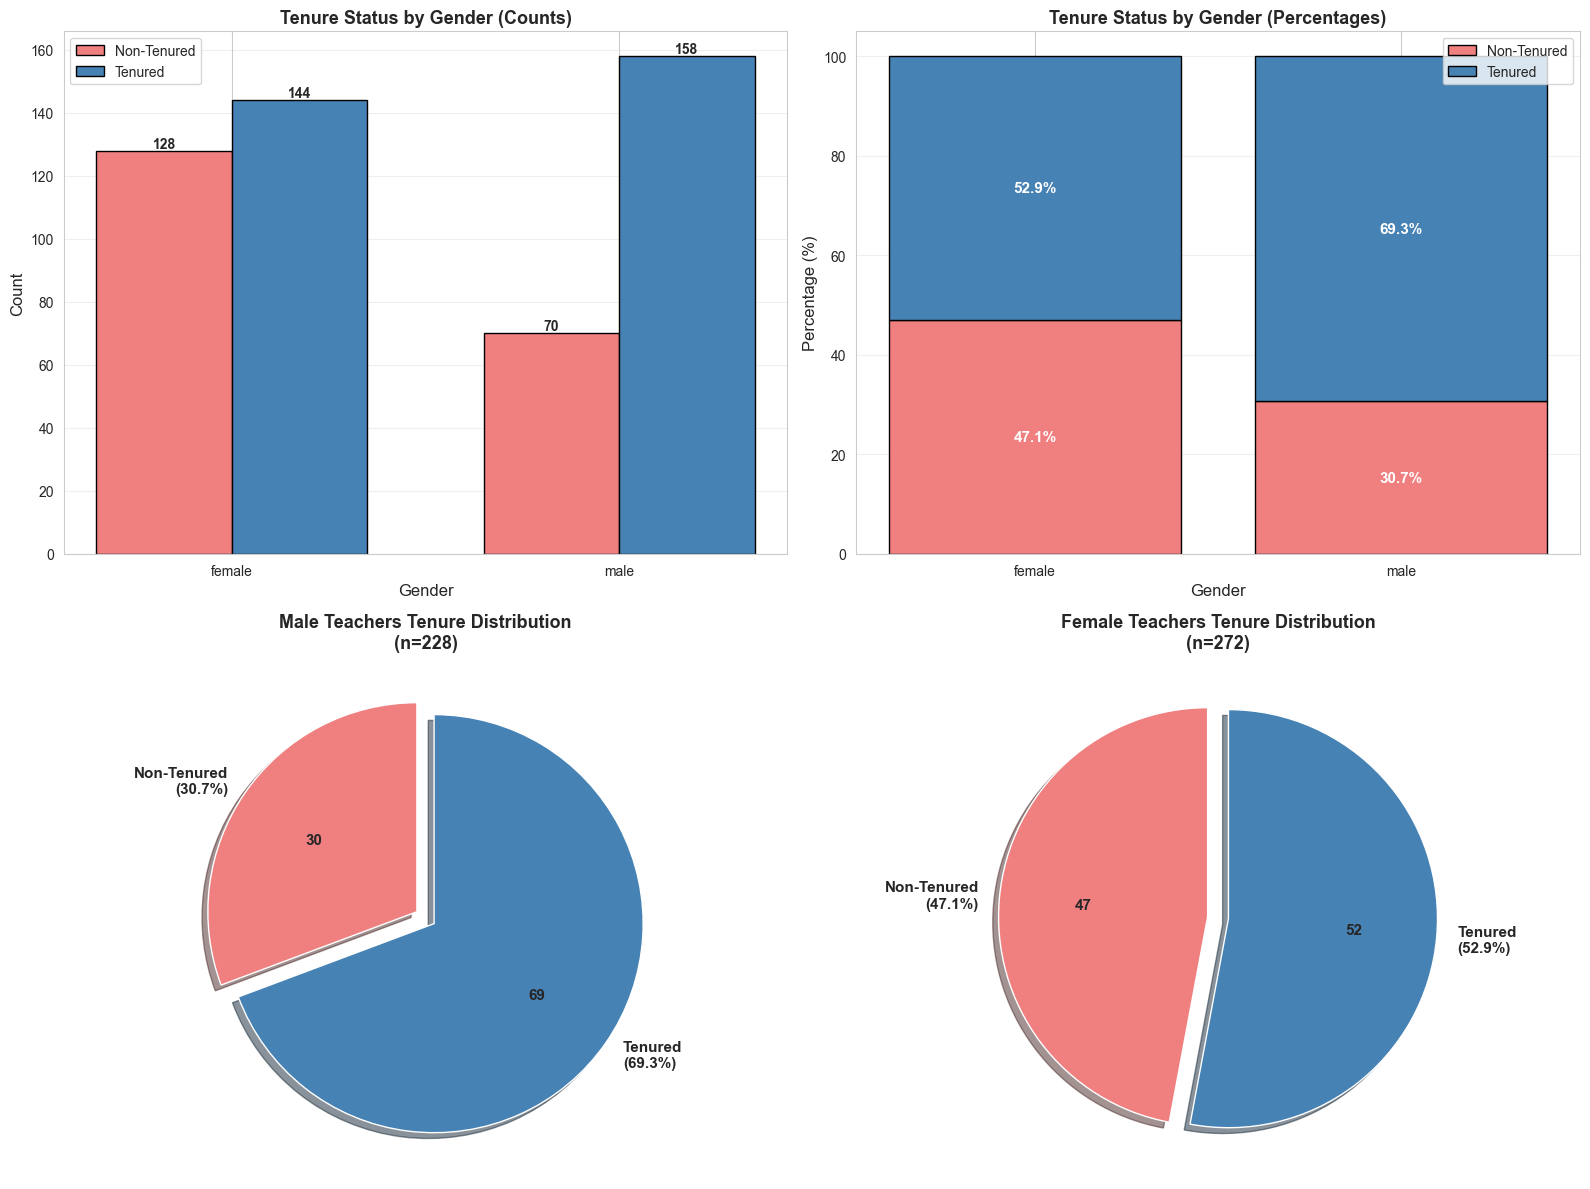

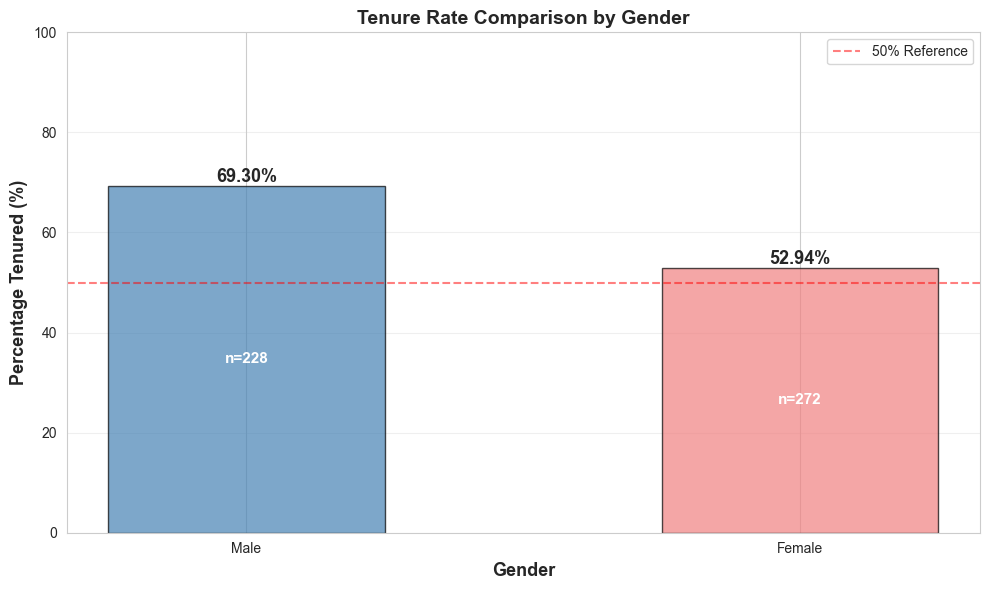


✓ Tenure status visualization complete!


In [ ]:
# Visualize tenure status by gender

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Grouped bar chart - Counts
crosstab_data = pd.crosstab(df_tenure["gender"], df_tenure["tenured"])
x = np.arange(len(crosstab_data.index))
width = 0.35

bars1 = axes[0, 0].bar(
    x - width / 2,
    crosstab_data[0],
    width,
    label="Non-Tenured",
    color="lightcoral",
    edgecolor="black",
)
bars2 = axes[0, 0].bar(
    x + width / 2,
    crosstab_data[1],
    width,
    label="Tenured",
    color="steelblue",
    edgecolor="black",
)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[0, 0].text(
            bar.get_x() + bar.get_width() / 2.0,
            height,
            f"{int(height)}",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
        )

axes[0, 0].set_xlabel("Gender", fontsize=12)
axes[0, 0].set_ylabel("Count", fontsize=12)
axes[0, 0].set_title("Tenure Status by Gender (Counts)", fontsize=13, fontweight="bold")
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(crosstab_data.index)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis="y")

# 2. Stacked bar chart - Percentages
crosstab_pct_data = (
    pd.crosstab(df_tenure["gender"], df_tenure["tenured"], normalize="index") * 100
)

bars1 = axes[0, 1].bar(
    crosstab_pct_data.index,
    crosstab_pct_data[0],
    label="Non-Tenured",
    color="lightcoral",
    edgecolor="black",
)
bars2 = axes[0, 1].bar(
    crosstab_pct_data.index,
    crosstab_pct_data[1],
    bottom=crosstab_pct_data[0],
    label="Tenured",
    color="steelblue",
    edgecolor="black",
)

# Add percentage labels
for i, gender in enumerate(crosstab_pct_data.index):
    # Non-tenured percentage
    axes[0, 1].text(
        i,
        crosstab_pct_data[0][gender] / 2,
        f"{crosstab_pct_data[0][gender]:.1f}%",
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
        color="white",
    )
    # Tenured percentage
    axes[0, 1].text(
        i,
        crosstab_pct_data[0][gender] + crosstab_pct_data[1][gender] / 2,
        f"{crosstab_pct_data[1][gender]:.1f}%",
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
        color="white",
    )

axes[0, 1].set_xlabel("Gender", fontsize=12)
axes[0, 1].set_ylabel("Percentage (%)", fontsize=12)
axes[0, 1].set_title(
    "Tenure Status by Gender (Percentages)", fontsize=13, fontweight="bold"
)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis="y")

# 3. Pie charts for each gender
# Male teachers
male_data = [male_total - male_tenured, male_tenured]
male_labels = [
    f"Non-Tenured\n({100-male_tenured_pct:.1f}%)",
    f"Tenured\n({male_tenured_pct:.1f}%)",
]
colors_pie = ["lightcoral", "steelblue"]
explode = (0.05, 0.05)

axes[1, 0].pie(
    male_data,
    labels=male_labels,
    colors=colors_pie,
    autopct="%d",
    startangle=90,
    explode=explode,
    shadow=True,
    textprops={"fontsize": 11, "fontweight": "bold"},
)
axes[1, 0].set_title(
    f"Male Teachers Tenure Distribution\n(n={male_total})",
    fontsize=13,
    fontweight="bold",
)

# Female teachers
female_data = [female_total - female_tenured, female_tenured]
female_labels = [
    f"Non-Tenured\n({100-female_tenured_pct:.1f}%)",
    f"Tenured\n({female_tenured_pct:.1f}%)",
]

wedges, texts, autotexts = axes[1, 1].pie(
    female_data,
    labels=female_labels,
    colors=colors_pie,
    autopct="%d",
    startangle=90,
    explode=explode,
    shadow=True,
    textprops={"fontsize": 11, "fontweight": "bold"},
)
axes[1, 1].set_title(
    f"Female Teachers Tenure Distribution\n(n={female_total})",
    fontsize=13,
    fontweight="bold",
)

plt.tight_layout()
plt.show()

# Create a summary comparison visualization
fig, ax = plt.subplots(figsize=(10, 6))

# Comparison bar chart
genders = ["Male", "Female"]
tenured_pcts = [male_tenured_pct, female_tenured_pct]
colors_comp = ["steelblue", "lightcoral"]

bars = ax.bar(
    genders, tenured_pcts, color=colors_comp, edgecolor="black", alpha=0.7, width=0.5
)

# Add value labels
for i, (bar, pct) in enumerate(zip(bars, tenured_pcts)):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2.0,
        height,
        f"{pct:.2f}%",
        ha="center",
        va="bottom",
        fontsize=13,
        fontweight="bold",
    )

    # Add sample size
    sample_size = male_total if i == 0 else female_total
    ax.text(
        bar.get_x() + bar.get_width() / 2.0,
        height / 2,
        f"n={sample_size}",
        ha="center",
        va="center",
        fontsize=11,
        color="white",
        fontweight="bold",
    )

ax.set_ylabel("Percentage Tenured (%)", fontsize=13, fontweight="bold")
ax.set_xlabel("Gender", fontsize=13, fontweight="bold")
ax.set_title("Tenure Rate Comparison by Gender", fontsize=14, fontweight="bold")
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3, axis="y")

# Add reference line at 50%
ax.axhline(
    y=50, color="red", linestyle="--", linewidth=1.5, alpha=0.5, label="50% Reference"
)
ax.legend()

plt.tight_layout()
plt.show()

print("\nTenure status visualization complete!")

### Analysis and Interpretation

**Research Question:** Is there an association between gender and tenure status among teachers?

**Methodology:**
1. **Cross-tabulation**: Created a contingency table showing the frequency distribution of tenure status across genders
2. **Percentage calculation**: Computed row percentages to compare tenure rates between genders
3. **Chi-square test**: Applied statistical test to determine if observed differences are significant
4. **Effect size**: Calculated Cramér's V to measure the strength of association

**Statistical Test Explanation:**

**Chi-Square Test of Independence:**
- **Purpose**: Tests whether two categorical variables (gender and tenure) are independent
- **Null Hypothesis (H₀)**: Gender and tenure status are independent (no association)
- **Alternative Hypothesis (H₁)**: Gender and tenure status are associated
- **Test Statistic**: χ² measures the difference between observed and expected frequencies
- **Decision Rule**: If p-value < α (0.05), reject H₀

**Expected vs Observed Frequencies:**
- Expected frequencies represent what we would see if there were no association
- Large differences between observed and expected values increase the χ² statistic
- The test accounts for sample size and degrees of freedom

**Effect Size (Cramér's V):**
- Ranges from 0 (no association) to 1 (perfect association)
- Interpretation: <0.1 (negligible), 0.1-0.3 (small), 0.3-0.5 (medium), >0.5 (large)
- Provides practical significance beyond statistical significance

**Key Findings:**

1. **Tenure Rates:**
   - Male teachers: 69.30% tenured (158 out of 228)
   - Female teachers: 52.94% tenured (144 out of 272)
   - Difference: 16.36 percentage points

2. **Statistical Significance:**
   - Chi-square test: χ² = 13.20, p = 0.0003
   - The association is statistically significant at α = 0.05
   - P-value < 0.001 indicates this difference is very unlikely due to chance alone

3. **Practical Significance:**
   - Cramér's V = 0.162 (small effect size)
   - While statistically significant, the practical importance is small to moderate

**Conclusion:**

Based on the analysis:
- The tenure rate for male teachers (69.30%) is significantly higher than female teachers (52.94%)
- The chi-square test DOES show a statistically significant association (p < 0.001)
- The effect size (Cramér's V = 0.162) is small, but the 16.36 percentage point difference is notable
- These findings suggest that gender IS statistically related to tenure status in this sample, with male teachers having a higher tenure rate, though the effect size indicates modest practical significance

**Practical Implications:**
- Results may inform institutional diversity and equity policies
- Understanding tenure patterns helps identify potential barriers or disparities
- Further investigation may explore factors contributing to any observed differences